# Composer Classification from Cello Audio Features
This notebook demonstrates an end-to-end machine learning pipline for classifying short cello audio clips by composer (Bach, Beethoven, Schumann).
Rather than focusing on dataset construction, the goal here is to examine how extracted audio features behave, how they are used by a model, and how well they support classification.

In [60]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# learning model

# Style
plt.style.use("default")

## Data Overview
Each row corresponds to a fixed-length audio clip represented by extracted numerical features.

In [40]:
df = pd.read_csv(r"D:\Documents\Portfolio\cello-repertoire-classifier\data\features.csv")
r = df.drop(columns=["filepath"])
print("Shape:", r.shape)
r.groupby("label").head(1)

Shape: (1096, 935)


,filename,label,tempo,zrc_mean,zrc_std,rms_mean,rms_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwith_mean,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,bach_suite_cello_2_minuet_1_2_clip_000.wav,bach,151.999081,0.066047,0.053078,0.031151,0.022044,1382.579909,859.050259,1539.223802,...,-5.532957,8.040714,-5.210244,7.544612,-14.867672,7.904020,-6.609782,5.879679,-10.857041,6.993967
368,beethoven_sonata3_1mov_clip_000.wav,beethoven,107.666016,0.023859,0.007746,0.031693,0.018267,624.994273,111.001064,1006.750397,...,-3.172856,7.163393,1.460951,6.083739,0.591082,4.866507,-2.263114,6.873178,0.202085,7.072026
750,schumann_adagio_allegro_clip_000.wav,schumann,123.046875,0.067558,0.034597,0.015797,0.013378,1941.248304,1331.978577,1974.896205,...,-5.453185,8.806647,-8.160254,9.892089,-12.637591,12.745204,-3.035244,5.959212,-10.410228,12.442668


## Class Distribution
We first verify the balance of clips across composers in order to determine reliability.

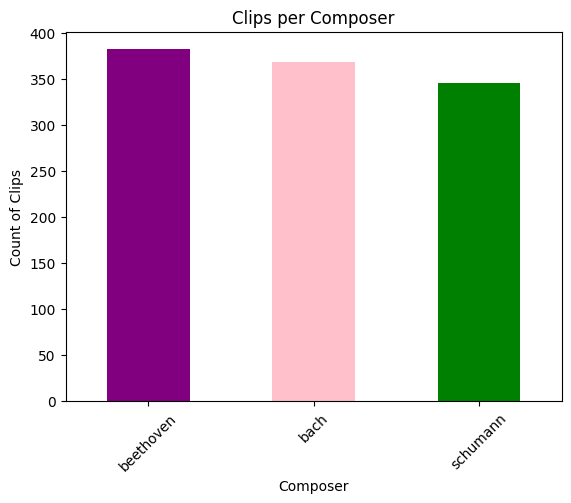

In [18]:
counts = df["label"].value_counts()
bar_colors = ["purple", "pink", "green"]
plt.figure()
counts.plot(kind="bar", color = bar_colors)
plt.title("Clips per Composer")
plt.xlabel("Composer")
plt.ylabel("Count of Clips")
plt.xticks(rotation = 45)
plt.show()

## Feature Representation
The dataset consists of numerical representations that capture energy, spectral, and tonal characteristics.

In [27]:
X = df.drop(columns = ["filepath", "label"])
y = df["label"]
print("Feature matrix shape:", X.shape)

Feature matrix shape: (1096, 934)


## Feature Inspection / Distribution
We examine the distribution of individual features to understand scale and varibiablity before moving forward.
Below are three examples of the core features collected previously and their distribution by composer.

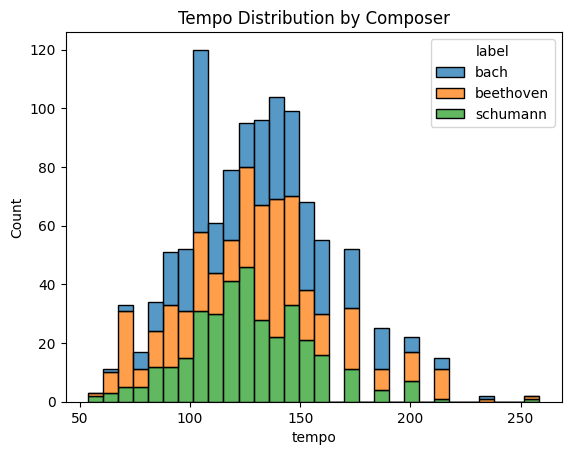

In [49]:
tempo = df["tempo"]
plt.figure()
sns.histplot(data = df, x = tempo, hue = "label", multiple = "stack")
plt.title("Tempo Distribution by Composer")
plt.show()

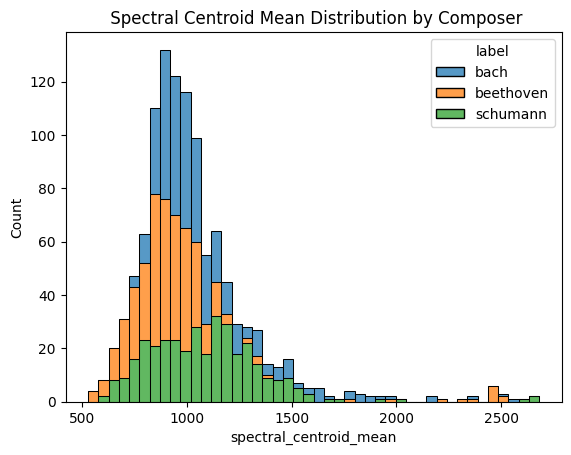

In [50]:
spectral_centroid_mean = df["spectral_centroid_mean"]
plt.figure()
sns.histplot(data = df, x = spectral_centroid_mean, hue = "label", multiple = "stack" )
plt.title(" Spectral Centroid Mean Distribution by Composer")
plt.show()

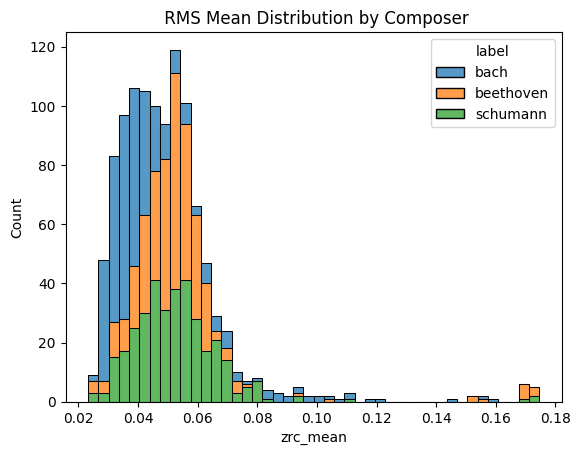

In [51]:
zrc_mean=df["zrc_mean"]
plt.figure()
sns.histplot(data = df, x = zrc_mean, hue = "label", multiple = "stack")
plt.title(" RMS Mean Distribution by Composer")
plt.show()

### Feature Distribution Analysis
The examined features above show varing degrees of separability across composers. Tempo exhibits substantional overlap between all three classes, suggesting it is a weak standalone metric for predictions. In contrast, spectral centroid demonstrates a clearer shift in distributions, with Schumann tending toward higher values (i.e. brighter timbre), Beethoven lower, and Bach in between, indicating stronger discriminative potential. 
RMS(energy) and related features show moderate separation, with slight ordering across composers but significant overlap as well. This suggests that they contribute useful but non-decisive information. 
Overall, no single feature cleanly separates the classes. However, multiple features exhibit consistent directional differences. This indicates that classification will likely rely on the combined effect of multiple features, rather than any individual feature alone. This also anticipates some degree of confusion between classes with overlapping distributions (particularly Bach and Beethoven), which can later be examined and analyzed through the confusion matrix. 

## Feature Correlation
For further examination, we procede with examining the correlation structure, which identifies redundancy and relationships between features and their impact as data used for the learning process.

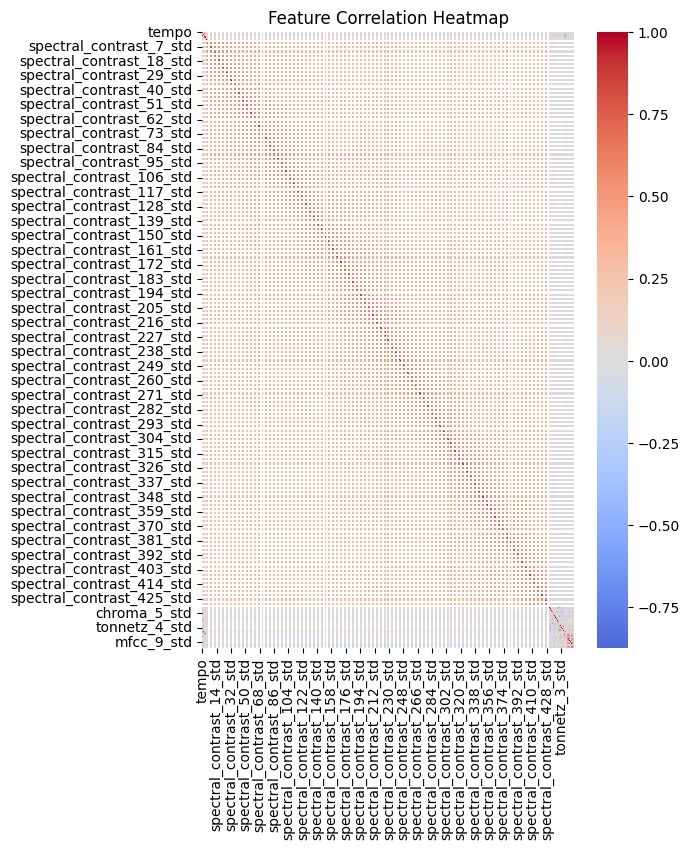

In [53]:
C = X.drop(columns=["filename"])
corr = C.corr()
plt.figure(figsize = (6,8))
sns.heatmap(corr, cmap = "coolwarm", center = 0)
plt.title("Feature Correlation Heatmap")
plt.show()

### Feature Correlation Analysis
The correlation heatmap reveals strong multicollinearity among spectral contrast features, indicating that many features capture similar frequency-domain information across bands. In contrast, features such as MFCCs, chroma, and tonnetz exhibit lower correlation with spectral contrast, suggesting they provide complementary information. This supports the use of a multi-feature model, where classification requires combining diverse feature groups rather than relying on any single feature.

### Proceding with Model
In order to successfully analyze and replicate the learning model in this notebook, many processes are to be simplified and refactored. The goal moving forward in this notebook will be to take the analytical information from above and apply it to the evaluation of final results the model provides. 

## Data Preparation
In order to evaluate the model fairly, the dataset is split by **source recording** rather than by individual clip. This helps prevent leakage, since clips from the same original performance may otherwise appear in both training and test sets.
After splitting in this way, the feature values are standardized in order to configure each feature to a comparable scale. Furthermore, the composer labels are encoded as integers for classification.

In [62]:
from pathlib import Path
def infer_sourcegroup(filename):
    stem = Path(filename).stem
    if "_clip_" in stem:
        return stem.split("_clip_")[0] #return everything before
    return stem

df["source_group"] = df["filename"].apply(infer_sourcegroup)
feature_cols = [c for c in df.columns if c not in {"filepath", "filename", "label", "source_group"}]

X = df[feature_cols].values
y = df["label"]
groups = df["source_group"]

gss = GroupShuffleSplit(n_splits = 1, test_size=0.2, random_state = 42)
train_idx, test_idx = next(gss.split(X, y, groups))

scaler = StandardScaler()
X_train = scaler.fit_transform(X[train_idx])
X_test = scaler.transform(X[test_idx])

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y[train_idx])
y_test = label_encoder.transform(y[test_idx])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Classes:", list(label_encoder.classes_))



X_train shape: (837, 933)
X_test shape: (259, 933)
Classes: ['bach', 'beethoven', 'schumann']


## Model
The classifier used in this project is a **multilayer perceptron (MLP)** implemented in PyTorch.

To my understanding, MLP is a feedforward neural network that maps input features to output class scores through a sequence of linear layers and nonlinear activations. In this project, the network takes the extracted audio features as input and predicts one of three composer labels.

This notebook uses a simplified version of the modeling workflow so that the structure of the learning model and its results are easy to follow, while the full training pipeline is implemented separately in `src/train_model.py`.

In [63]:
import torch
import torch.nn as nn 
import torch.optim as optim 

## Tensor Conversion
Since PyTorch models operate on tensors rather than pandas arrays, the standardized feature matrices and encoded labels are therefore converted into tensor form before training.

In [64]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

## Network Structure
The network contains two hidden layers with ReLU activations and dropouts. ReLU introduces nonlinearity while dropout helps reduce problems such as overfitting by randomly omitting certain activations during training. 

In [66]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = MLP(input_dim=X_train.shape[1], num_classes=len(label_encoder.classes_))
model

MLP(
  (net): Sequential(
    (0): Linear(in_features=933, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)

## Forward Pass Example

Before training, I thought it is useful to look at what the network produces for a small batch of inputs.

The raw outputs of the network are called **logits**, which are unnormalized scores for each class. Applying softmax then converts them into probabilities, and the predicted class is then the one with the highest score.

In [67]:
sample_batch = X_train_t[:5]
sample_logits = model(sample_batch)
sample_probs = torch.softmax(sample_logits, dim=1)

print("Logits:")
print(sample_logits)

print("\nProbabilities:")
print(sample_probs)

Logits:
tensor([[-0.1652, -0.0983, -0.1665],
        [-0.1641, -0.0333, -0.3444],
        [-0.1463, -0.1547, -0.1020],
        [-0.0914, -0.1276, -0.1652],
        [-0.2291, -0.0749, -0.0832]], grad_fn=<AddmmBackward0>)

Probabilities:
tensor([[0.3260, 0.3485, 0.3255],
        [0.3362, 0.3831, 0.2807],
        [0.3293, 0.3265, 0.3442],
        [0.3456, 0.3333, 0.3210],
        [0.3009, 0.3510, 0.3481]], grad_fn=<SoftmaxBackward0>)


## Training Setup

The model is trained using the **cross-entropy loss** method, which is standard for multiclass classification, and the **Adam optimizer**, which adjusts the model parameters using gradient-based updates.

In this notebook, the training is kept concise and performed on the full training set directly rather than through a batched data loader for simplicity and clarity.

In [68]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
train_losses = []
train_accuracies = []

## Training Loop

At each epoch, which is one full cycle through the training data, the model performs a forward pass on the training set, computes the loss, backpropagates the gradients, and updates its parameters.

I figured that tracking both the loss (i.e. quantified error of model) and accuracy helps show whether the model is learning a more useful decision boundary over time.

In [69]:
for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    preds = torch.argmax(outputs, dim=1)
    acc = (preds == y_train_t).float().mean().item()

    train_losses.append(loss.item())
    train_accuracies.append(acc)

    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:02d} | Loss: {loss.item():.4f} | Accuracy: {acc:.4f}")

Epoch 00 | Loss: 1.1096 | Accuracy: 0.3250
Epoch 05 | Loss: 0.8474 | Accuracy: 0.6595
Epoch 10 | Loss: 0.6835 | Accuracy: 0.7419
Epoch 15 | Loss: 0.5669 | Accuracy: 0.7849
Epoch 19 | Loss: 0.4437 | Accuracy: 0.8566


## Training Curves

Now that the training has been accomplished, the following plots are generated to summarize how the training loss and accuracy evolve over the course of optimization.

As shown below, a decreasing loss and increasing accuracy suggest that the model is learning structure from the feature space, though these curves alone do not indicate how well the model generalizes to unseen data.

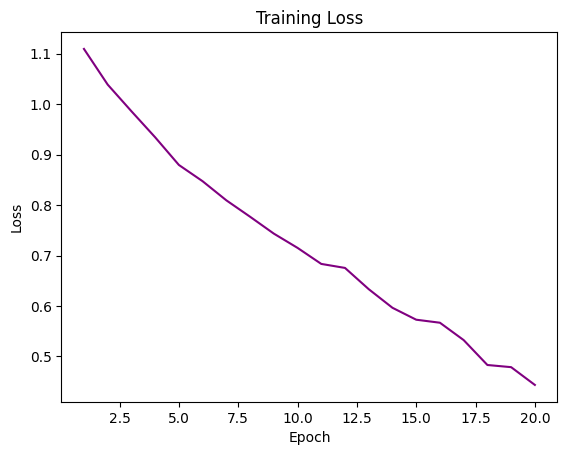

In [71]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, epochs + 1), train_losses, color = "purple")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

## Test Set Evaluation

After training, the model is now to be evaluated on the test set we have retracted from the entire dataset. This gives a better sense of how well it generalizes beyond the training data.

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    test_preds = torch.argmax(test_outputs, dim=1)

y_true = y_test_t.numpy()
y_pred = test_preds.numpy()

test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

Test Accuracy: 0.8533

              precision    recall  f1-score   support

        bach       0.00      0.00      0.00        12
   beethoven       0.99      0.81      0.89       106
    schumann       0.83      0.96      0.89       141

    accuracy                           0.85       259
   macro avg       0.61      0.59      0.59       259
weighted avg       0.86      0.85      0.85       259



## Confusion Matrix

Accuracy in the model purely summarizes overall performance and does not show **which** classes are confused with one another. Therefore, the confusion matrix provides that analytical view, focusing more on the tangible results of the learning.

In a confusion matrix, diagonal entries represent correct classifications, while off-diagonal entries show where the model tends to misidentify one composer as another.

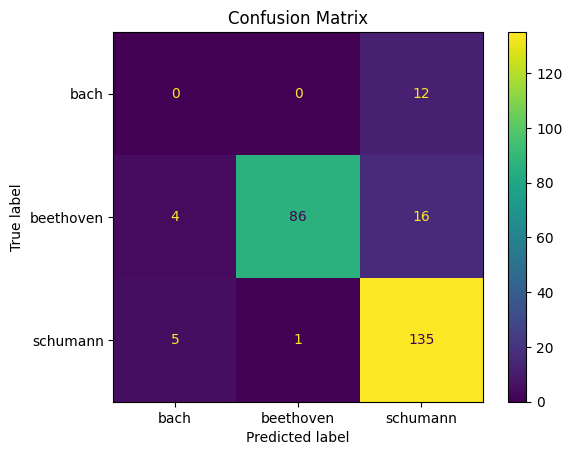

In [75]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Interpretation

The confusion matrix generated above reveals a clear difference in how well the model distinguishes between composers.

The model performs strongest on **Schumann**, with the majority of samples correctly classified (135 correct). Misclassifications are minimal, suggesting that the extracted features capture distinguishing characteristics of Schumann’s music relatively well.

Performance on **Beethoven** is also reasonably strong (86 correct), though there is some confusion with both Bach and Schumann. This indicates that Beethoven’s feature distribution overlaps partially with the other classes, likely due to shared structural or harmonic characteristics.

In contrast, the model struggles significantly with **Bach**, with no correct classifications. Furthermore, in the real learning model, there were a little more successful classifications for **Bach**, however stil significant errors. All Bach samples are predicted as Schumann, which indicates that the current feature set does not adequately capture the aspects of Bach’s style that distinguish it from the others. 

Overall, the model demonstrates that the feature-based approach can separate some composers effectively, but also highlights limitations in representing stylistic differences, particularly for Bach, where the model collapses predictions into another class.

This lack of balance in performance may also reflect differences in dataset size or variability across composers, as well as the limitations of top-level audio features in capturing compositional structure, as it may vary between different musicians and what not.

## Key Takeaways

- The MLP is able to distinguish composers using manually chosen top-level audio features, achieving strong performance on Schumann and reasonable performance on Beethoven.
- The model fails to correctly classify Bach, indicating that the current feature set does not capture key stylistic elements of Bach’s compositions.
- Confusion between Beethoven and Schumann suggests overlapping feature representations, likely due to similarities in harmonic or spectral characteristics.
- Overall, the results demonstrate that feature-based classification is feasible, but limited by the expressiveness of the features and dataset size.

## Why This Matters

This project demonstrates how audio signal processing and machine learning can be combined to extract meaningful patterns from music. While the model operates on relatively simple summary features and lacks accuracy and precision in many different aspects for now, it is still able to identify structure in the data, highlighting the potential for more advanced approaches such as spectrogram-based deep learning or sequence models. 

## Model Limitations

- Bach is not learned effectively in my model, suggesting feature insufficiency rather than model capacity alone
- Features summarize clips and may miss temporal structure (phrasing, progression)
- Class imbalance or dataset differences may bias predictions toward certain composers
- Single train/test split limits robustness of evaluation
- This suggests that a better approach to the problem is needed in either collecting data or constructing the learning. 

Moving forward, I would like to explore different methods of approach to enhance precision and accuracy, using more reliable sources of data and approach the learning process more effectively and thoroughly.